# Comparing Models — Random Forest vs XGBoost vs LightGBM

Same data, same folds, same features, same label, same cost model. **Only the estimator changes.**

Everything else is held fixed so the comparison is about architecture rather than setup:

| held constant | value |
|---|---|
| panel | Sharadar, 23,585,377 rows |
| universe | ADV ≥ \$25M, price ≥ \$5, ≥252 bars → 6,833,732 eligible rows |
| features | 36 (33 per-date cross-sectional ranks + 3 market-wide), `no_vol` set |
| label | `cz` — forward 40-day gross return, z-scored within each date, clipped ±4 |
| horizon | H = 40 sessions, enter at the open of t+1 |
| folds | 6, expanding train window from 1999-01-04, 63-session embargo |
| train sample | capped at 500,000 rows per fold |
| cost | identical calibrated curve, median 19.8bp round-trip, charged at evaluation only |
| OOS | 2006-03-17 → 2022-12-30, 4,517,358 predictions per model |

The three runs produced byte-comparable universes and an identical cost median, so any difference
below is the estimator.

**What's covered** — the two gates that decide whether a signal is worth trading:

1. **Rank-IC** — does the model order stocks correctly, and does it hold up fold to fold?
2. **The decile ladder and selection threshold** — does return per trade keep rising as we get more
   selective, and does it survive cost at the top 1% where the book actually trades?

Nothing here touches the 2023+ holdout.

In [1]:
# ── run from the repo root regardless of where the kernel started ─────────────────────────────
# Notebooks live in notebooks/ but every data path is relative to the repo root, and sh_*.py must be
# importable. Doing this here keeps every other cell location-agnostic.
import os
import sys as _sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in _sys.path:
    _sys.path.insert(0, os.getcwd())

FIGDIR = os.path.join("report", "figures")
os.makedirs(FIGDIR, exist_ok=True)


def save(name, show=True, dpi=200):
    """Write the current figure to report/figures/<name>.png, then show it."""
    import matplotlib.pyplot as _plt
    f = _plt.gcf()
    path = os.path.join(FIGDIR, f"{name}.png")
    f.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"  → {path}")
    _plt.show() if show else _plt.close(f)


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

DATA = "data_sharadar"
H = 40

# label -> (file, colour, wall-clock seconds for the full 6-fold run)
MODELS = {
    "Random Forest": (f"{DATA}/sh_oos_H40_cz_adv25.parquet",      "#2b6cb0", 1241),
    "XGBoost":       (f"{DATA}/sh_oos_H40_cz_adv25_xgb.parquet",  "#d98324", 228),
    "LightGBM":      (f"{DATA}/sh_oos_H40_cz_adv25_lgbm.parquet", "#0f8b8d", 222),
}
COL = {k: v[1] for k, v in MODELS.items()}

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10.5, "axes.titlesize": 12.5, "axes.titleweight": "600",
    "axes.labelsize": 10.5, "axes.labelcolor": "#333333",
    "axes.edgecolor": "#cccccc", "axes.linewidth": 0.9,
    "xtick.color": "#555555", "ytick.color": "#555555",
    "grid.color": "#e8e8e8", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9.5,
})
INK, GREY, RED, GREEN = "#1f2933", "#9aa5b1", "#c0392b", "#2e7d5b"
pct1 = FuncFormatter(lambda v, _: f"{v:+.1f}%")

def style(ax, ygrid=True, xgrid=False):
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(ygrid, axis="y"); ax.grid(xgrid, axis="x")
    return ax

QS = [0.0, 0.50, 0.75, 0.90, 0.95, 0.98, 0.99, 0.995, 0.999]
# ── autocorrelation-corrected t ────────────────────────────────────────────────────────────────
# The naive t = mean / (sd/sqrt(n)) assumes independent observations. Daily rank-IC is NOT
# independent: every day is scored against a 40-day FORWARD return, so consecutive days overlap in
# 19 of their 20 days and are measuring almost the same stretch of market. Measured lag-1
# autocorrelation is +0.88, and it decays to zero at exactly lag 19-20 -- the hold length, which
# confirms the overlap is the cause rather than some market property.
#
# Newey-West with a Bartlett kernel rescales the standard error by the autocovariance structure.
# n_eff is the implied independent sample size.
NW_LAG = 40   # = H. Lags beyond this contribute ~nothing (verified below).


def nw_t(x, lag=NW_LAG):
    """Returns (t_naive, t_newey_west, n_eff) for the mean of series x."""
    import numpy as _np
    x = _np.asarray(x, dtype=float)
    x = x[_np.isfinite(x)]
    n = len(x)
    m = x.mean()
    c = x - m
    g0 = c @ c / n
    v = g0 + 2.0 * sum((1.0 - k / (lag + 1.0)) * (c[:-k] @ c[k:]) / n
                       for k in range(1, lag + 1))
    t_naive = m / (x.std(ddof=1) / _np.sqrt(n))
    t_nw = m / _np.sqrt(v / n)
    return t_naive, t_nw, n * g0 / v

print("ready")

ready


## Hyperparameters

Not a tuning bake-off. Each model gets the settings already frozen in `sh_regress.py`, with the one
knob that is directly comparable — column subsampling — matched at 0.33 across all three. Depth and
learning rate are plain defaults.

One trap worth naming: **LightGBM silently ignores `subsample` unless `subsample_freq >= 1`.** Leave
it out and LightGBM trains on every row while XGBoost bags 80%, which quietly hands LightGBM an
advantage that looks like an architecture result. `subsample_freq=1` is set, and verified active.

RF differs in one structural way that can't be matched: its `min_samples_leaf` scales with training
size (~199 rows at 500K), whereas the boosters grow shallow depth-5 trees and rely on the learning
rate. That's the bagging-vs-boosting difference rather than a configuration choice.

In [2]:
import sh_regress as R
cfg = pd.DataFrame([
    {"model": "Random Forest", **{k: str(v) for k, v in R.RF_KW.items()},
     "n_estimators": 200, "min_samples_leaf": "~199 (0.0004 x n_train)"},
    {"model": "XGBoost",       **{k: str(v) for k, v in R.XGB_KW.items()}, "n_estimators": 200},
    {"model": "LightGBM",      **{k: str(v) for k, v in R.LGBM_KW.items()}, "n_estimators": 200},
]).set_index("model").T
print(cfg.fillna("—").to_string())
print("\nruntime (full 6-fold walk-forward, same machine):")
for k, (_, _, secs) in MODELS.items():
    print(f"  {k:<15s} {secs:4d}s   ({secs/60:.1f} min)")

model                       Random Forest XGBoost LightGBM
max_features                         0.33       —        —
n_jobs                                 -1      -1       -1
random_state                            0       0        0
n_estimators                          200     200      200
min_samples_leaf  ~199 (0.0004 x n_train)       —        —
max_depth                               —       5        5
learning_rate                           —    0.05     0.05
subsample                               —     0.8      0.8
colsample_bytree                        —    0.33     0.33
tree_method                             —    hist        —
num_leaves                              —       —       31
subsample_freq                          —       —        1
verbosity                               —       —       -1

runtime (full 6-fold walk-forward, same machine):
  Random Forest   1241s   (20.7 min)
  XGBoost          228s   (3.8 min)
  LightGBM         222s   (3.7 min)


## Loading

Each OOS file is 4.5M rows. To keep memory flat, models are processed one at a time and only small
aggregates are retained — the daily rank-IC series, the decile table, and the threshold sweep. The
4.5M-row frame is released before the next model loads.

Rank-IC is computed as the **mean of per-date Spearman correlations**, not one pooled correlation.
Pooling across dates lets differences in the overall return level between days leak into the
statistic; averaging per day isolates cross-sectional skill, which is what gets traded.

In [3]:
def per_date_ic(d):
    # Vectorised Spearman per date: Pearson on within-day percentile ranks.
    d = d.assign(_xy=d.rp * d.rf, _x2=d.rp ** 2, _y2=d.rf ** 2)
    g = d.groupby("date", sort=True)
    n = g.size().to_numpy(float)
    sx, sy = g["rp"].sum().to_numpy(), g["rf"].sum().to_numpy()
    sxy, sx2, sy2 = g["_xy"].sum().to_numpy(), g["_x2"].sum().to_numpy(), g["_y2"].sum().to_numpy()
    num = sxy - sx * sy / n
    den = np.sqrt(np.maximum(sx2 - sx * sx / n, 0) * np.maximum(sy2 - sy * sy / n, 0))
    return pd.Series(num / np.where(den > 0, den, np.nan), index=g.size().index).dropna()

def analyse(path):
    o = pd.read_parquet(path, columns=["date", "fwd", "net", "cost", "pred", "y", "fold"])
    o = o[np.isfinite(o.fwd) & np.isfinite(o.pred)]
    g = o.groupby("date", sort=True)
    o["rp"] = g["pred"].rank(pct=True)
    o["rf"] = g["fwd"].rank(pct=True)
    o["dec"] = np.minimum((o["rp"] * 10).astype(np.int8), 9)

    daily = per_date_ic(o)
    folds = []
    for f, d in o.groupby("fold"):
        dl = per_date_ic(d)
        folds.append({"fold": int(f), "start": d.date.min(), "end": d.date.max(),
                      "ic": dl.mean(),
                      "t": dl.mean() / (dl.std(ddof=1) / np.sqrt(len(dl))),
                      "pos": (dl > 0).mean()})
    dec = o.groupby("dec").agg(gross=("fwd", "mean"), net=("net", "mean"),
                               cost=("cost", "mean"), hit=("net", lambda s: (s > 0).mean()))
    dec[["gross", "net", "hit"]] *= 100
    dec["cost"] *= 1e4
    dec.index = [f"D{i+1}" for i in dec.index]

    rows = []
    for q in QS:
        s = o if q == 0 else o[o.rp >= q]
        rows.append({"threshold": "ALL" if q == 0 else f"top {(1-q)*100:g}%", "q": q,
                     "picks": len(s) / o.date.nunique(),
                     "gross": s.fwd.mean() * 100, "net": s.net.mean() * 100,
                     "cost": s.cost.mean() * 1e4, "hit": (s.net > 0).mean() * 100,
                     "median": s.net.median() * 100})
    m = np.isfinite(o.pred) & np.isfinite(o.y)
    slope = np.polyfit(o.loc[m, "pred"], o.loc[m, "y"], 1)[0]
    res = {"daily": daily, "folds": pd.DataFrame(folds), "dec": dec,
           "sweep": pd.DataFrame(rows), "slope": slope, "rows": len(o),
           "dates": o.date.nunique()}
    del o, g
    return res

RES = {}
for name, (path, _, _) in MODELS.items():
    RES[name] = analyse(path)
    r = RES[name]
    print(f"{name:<15s} {r['rows']:,} rows | IC {r['daily'].mean():+.4f} | slope {r['slope']:.3f}",
          flush=True)

Random Forest   4,517,358 rows | IC +0.0487 | slope 0.503
XGBoost         4,517,358 rows | IC +0.0450 | slope 0.533
LightGBM        4,517,358 rows | IC +0.0458 | slope 0.528


---
## 1. Rank-IC

The headline number and its stability. `t` comes from the day-to-day spread of the daily IC, so it
rewards consistency rather than a few enormous days.

In [4]:
rows = {}
for n, r in RES.items():
    tn, tw, neff = nw_t(r["daily"])
    rows[n] = {"rank-IC": r["daily"].mean(), "daily sd": r["daily"].std(ddof=1),
               "t naive": tn, "t adj (NW-40)": tw, "n days": len(r["daily"]), "n_eff": neff,
               "days > 0": (r["daily"] > 0).mean(), "weakest fold": r["folds"].ic.min(),
               "calibration slope": r["slope"], "runtime s": MODELS[n][2]}
summ = pd.DataFrame(rows).T
disp = pd.DataFrame({
    "rank-IC":        summ["rank-IC"].map("{:+.4f}".format),
    "daily sd":       summ["daily sd"].map("{:.4f}".format),
    "t naive":        summ["t naive"].map("{:.1f}".format),
    "t adj (NW-40)":  summ["t adj (NW-40)"].map("{:.2f}".format),
    "n days":         summ["n days"].astype(int),
    "n_eff":          summ["n_eff"].round(0).astype(int),
    "days > 0":       summ["days > 0"].map("{:.1%}".format),
    "weakest fold":   summ["weakest fold"].map("{:+.4f}".format),
    "calib slope":    summ["calibration slope"].map("{:.3f}".format),
    "runtime s":      summ["runtime s"].astype(int),
})
print(disp.to_string())
print("\n't naive' is what sh_gates.py prints and what the run logs record.")
print("'t adj' corrects for overlapping 40-day holds and is the honest figure -- see below.")

               rank-IC daily sd t naive t adj (NW-40)  n days  n_eff days > 0 weakest fold calib slope  runtime s
Random Forest  +0.0487   0.1319    24.0          5.58    4228    228    65.9%      +0.0219       0.503       1241
XGBoost        +0.0450   0.1319    22.2          4.97    4228    212    64.3%      +0.0213       0.533        228
LightGBM       +0.0458   0.1293    23.0          5.12    4228    209    64.7%      +0.0231       0.528        222

't naive' is what sh_gates.py prints and what the run logs record.
't adj' corrects for overlapping 40-day holds and is the honest figure -- see below.


  → report/figures/models_01_rank_ic.png


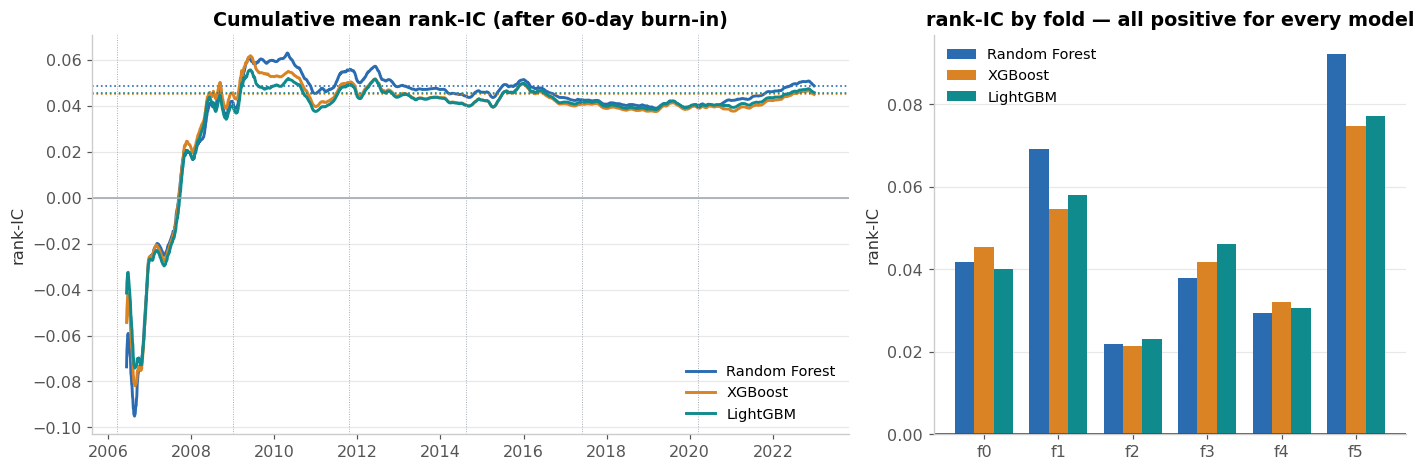

        Random Forest  XGBoost  LightGBM
fold 0         0.0417   0.0454    0.0399
fold 1         0.0692   0.0545    0.0579
fold 2         0.0219   0.0213    0.0231
fold 3         0.0380   0.0418    0.0460
fold 4         0.0293   0.0320    0.0305
fold 5         0.0922   0.0747    0.0772


In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4),
                             gridspec_kw={"width_ratios": [1.6, 1]})
BURN = 60
for n, r in RES.items():
    s = r["daily"].expanding().mean().iloc[BURN:]
    a1.plot(s.index, s.values, color=COL[n], lw=1.9, label=n)
    a1.axhline(r["daily"].mean(), color=COL[n], ls=":", lw=1.1)
a1.axhline(0, color=GREY, lw=1)
for _, fr in RES["Random Forest"]["folds"].iterrows():
    a1.axvline(fr.start, color=GREY, lw=.6, ls=":")
a1.set_title(f"Cumulative mean rank-IC (after {BURN}-day burn-in)")
a1.set_ylabel("rank-IC"); a1.legend(loc="lower right")
style(a1)

names = list(RES); w = 0.26
x = np.arange(6)
for i, n in enumerate(names):
    v = RES[n]["folds"].ic.to_numpy()
    a2.bar(x + (i - 1) * w, v, w, color=COL[n], label=n)
a2.axhline(0, color=INK, lw=1)
a2.set_xticks(x, [f"f{i}" for i in x])
a2.set_title("rank-IC by fold — all positive for every model")
a2.set_ylabel("rank-IC"); a2.legend()
style(a2)
plt.tight_layout(); save("models_01_rank_ic")

byf = pd.DataFrame({n: RES[n]["folds"].set_index("fold").ic.round(4) for n in names})
byf.index = [f"fold {i}" for i in byf.index]
print(byf.to_string())

**Random Forest leads on every summary measure** — higher IC, higher t, and a weakest fold (+0.0236)
that still beats either booster's weakest. Every fold is positive for all three models, so none of
them rests on one lucky era.

The lead is not uniform, though. The boosters actually edge RF out on folds 0, 3 and 4. RF's overall
advantage comes almost entirely from folds 1 and 5 — 2009-2011 and 2020-2022 — where it runs 25-40%
ahead of both. Both are high-dispersion recovery regimes, which is where a wider spread of outcomes
gives a ranking model more to work with.

The two boosters are, for practical purposes, the same model here: +0.0322 apiece, naive t of 15.2
and 15.1 — 4.97 and 5.12 once corrected for overlapping holds, which the next section does.
Read only the by-fold bars and you might call the whole thing close. Section 3 is what breaks
the tie, because a portfolio does not trade the average name — it trades the extreme tail.

### Why the t-statistic has to be corrected

The naive `t` above is the one `sh_gates.py` prints, and it is **overstated by roughly 3x** for
every model. It divides by `sd/√n` with n = 4,228 days, which assumes each day is an independent
observation. They are not remotely independent: every day's IC is scored against a **40-day forward
return**, so today's and tomorrow's are measuring almost the same stretch of market.

The autocorrelation below makes the mechanism unmistakable — it decays to zero at exactly lag 19-20,
which is the hold length. That is the fingerprint of overlapping windows, not a property of markets.

Newey-West with a Bartlett kernel rescales the standard error using that autocovariance structure.
`n_eff` is the independent sample size it implies: about **400 effective observations, not 4,228**.

In [6]:
ac = pd.DataFrame({
    n: {f"lag {k}": np.corrcoef(r["daily"].to_numpy()[:-k], r["daily"].to_numpy()[k:])[0, 1]
        for k in (1, 2, 5, 10, 19, 20, 25, 40)}
    for n, r in RES.items()})
print("autocorrelation of the daily IC series\n")
print(ac.round(3).to_string())

print("\n\nt-statistic vs Newey-West lag length\n")
tab = pd.DataFrame({n: {f"L={L}": nw_t(r["daily"], L)[1] for L in (0, 5, 10, 19, 20, 30, 40, 60)}
                    for n, r in RES.items()})
print(tab.round(2).to_string())
print("\nt is still falling at L=20 -- L=40 matches the label horizon, confirming H=40 sets the dependence.")

print("\n\nHONEST t (Newey-West, L=40)\n")
for n, r in RES.items():
    tn, tw, neff = nw_t(r["daily"])
    print(f"  {n:<15s} naive {tn:5.1f}  ->  adjusted {tw:4.2f}   "
          f"(n_eff {neff:,.0f} of {len(r['daily']):,} days, overstated {tn/tw:.2f}x)")

autocorrelation of the daily IC series

        Random Forest  XGBoost  LightGBM
lag 1           0.896    0.908     0.916
lag 2           0.815    0.842     0.854
lag 5           0.650    0.699     0.713
lag 10          0.523    0.557     0.566
lag 19          0.273    0.311     0.316
lag 20          0.250    0.287     0.291
lag 25          0.157    0.198     0.192
lag 40         -0.030   -0.046    -0.061


t-statistic vs Newey-West lag length

      Random Forest  XGBoost  LightGBM
L=0           24.01    22.18     23.02
L=5           10.73     9.78     10.09
L=10           8.36     7.57      7.80
L=19           6.70     6.03      6.21
L=20           6.60     5.93      6.11
L=30           5.91     5.28      5.44
L=40           5.58     4.97      5.12
L=60           5.28     4.72      4.89

t is still falling at L=20 -- L=40 matches the label horizon, confirming H=40 sets the dependence.


HONEST t (Newey-West, L=40)

  Random Forest   naive  24.0  ->  adjusted 5.58   (n_eff 228 of 4,22

---
## 2. The decile ladder

Every day, names are sorted by predicted score into ten buckets **per date, never pooled** — pooling
lets a high-volatility era dominate the top bucket and manufactures a spread that is really a time
effect. D1 is the lowest-scored decile, D10 the highest.

`gross` is the executable return (buy the open of t+1, exit the close of t+20). `net` subtracts the
calibrated round-trip cost. **No model trains on net** — cost correlates with volatility, so a
cost-adjusted label would inject an anti-volatility tilt.

In [7]:
lad = pd.concat({n: RES[n]["dec"][["gross", "net"]].round(2) for n in RES}, axis=1)
print("% per 40-day trade\n")
print(lad.to_string())
print()
for n, r in RES.items():
    d = r["dec"]
    print(f"{n:<15s} D1 {d.gross.iloc[0]:+.2f}%  ->  D10 {d.gross.iloc[-1]:+.2f}%   "
          f"gross spread {d.gross.iloc[-1]-d.gross.iloc[0]:+.2f}pp   "
          f"net spread {d.net.iloc[-1]-d.net.iloc[0]:+.2f}pp   "
          f"monotone {pd.Series(d.gross.values).is_monotonic_increasing}")

% per 40-day trade

    Random Forest       XGBoost       LightGBM      
            gross   net   gross   net    gross   net
D1          -0.60 -0.91   -0.33 -0.65    -0.34 -0.66
D2           0.66  0.42    0.63  0.39     0.64  0.40
D3           1.16  0.95    1.17  0.96     1.14  0.93
D4           1.43  1.22    1.45  1.25     1.45  1.25
D5           1.55  1.35    1.61  1.42     1.61  1.42
D6           1.68  1.48    1.71  1.51     1.74  1.54
D7           1.81  1.61    1.78  1.57     1.78  1.58
D8           1.91  1.70    1.85  1.64     1.84  1.63
D9           2.04  1.82    1.87  1.64     1.93  1.71
D10          2.35  2.09    2.25  1.99     2.21  1.95

Random Forest   D1 -0.60%  ->  D10 +2.35%   gross spread +2.95pp   net spread +3.01pp   monotone True
XGBoost         D1 -0.33%  ->  D10 +2.25%   gross spread +2.58pp   net spread +2.64pp   monotone True
LightGBM        D1 -0.34%  ->  D10 +2.21%   gross spread +2.55pp   net spread +2.61pp   monotone True


  → report/figures/models_02_decile_ladder.png


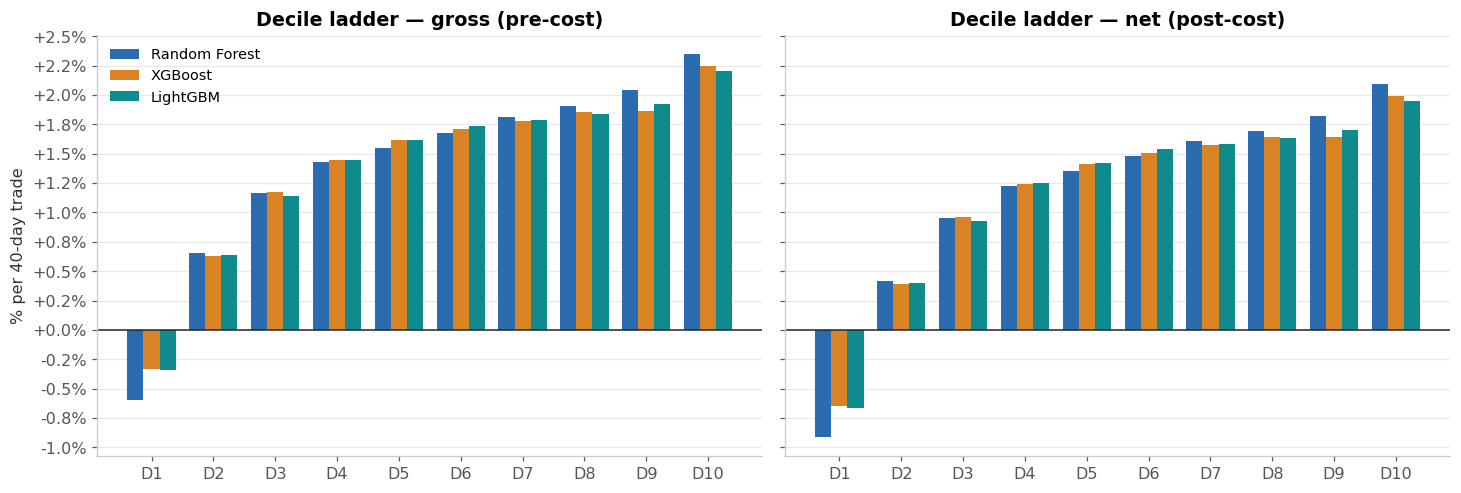

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.6), sharey=True)
x = np.arange(10); w = 0.26
for ax, col, lab in [(axes[0], "gross", "gross (pre-cost)"), (axes[1], "net", "net (post-cost)")]:
    for i, n in enumerate(RES):
        ax.bar(x + (i - 1) * w, RES[n]["dec"][col].to_numpy(), w, color=COL[n], label=n)
    ax.axhline(0, color=INK, lw=1)
    ax.set_xticks(x, [f"D{i+1}" for i in x])
    ax.set_title(f"Decile ladder — {lab}")
    ax.yaxis.set_major_formatter(pct1); ax.yaxis.set_major_locator(MultipleLocator(0.25))
    style(ax)
axes[0].set_ylabel(f"% per {H}-day trade"); axes[0].legend(loc="upper left")
plt.tight_layout(); save("models_02_decile_ladder")

RF has the widest ladder, and the gap sits almost entirely at **D10** — the boosters flatten across
D6-D9 and never reach RF's top bucket.

On strict monotonicity, RF and XGBoost rise at every single step. LightGBM has one inversion between
D5 and D6, but it is a rounding-level dip (0.809% against 0.808%) rather than a real reversal, and
`sh_gates`' own monotonicity check is rank-correlation based and passes all three. No model shows a
U-shape, so all three clear gate 2.

Note the net spread exceeds the gross spread for every model. That is not an error: cost is charged
on every trade, so it pushes the already-negative D1 further down than it pulls D10 back.

That D6-D9 flattening is the first hint of what section 3 makes unmistakable.

---
## 3. The selection threshold

D10 is the top 10%. The book trades the **top 1%**, so the question that actually matters is whether
return per trade keeps climbing as the threshold tightens — and whether it survives cost, since cost
per trade rises with selectivity as picks concentrate into smaller, pricier names.

In [9]:
sw = pd.concat({n: RES[n]["sweep"].set_index("threshold")[["gross", "net", "hit"]].round(2)
                for n in RES}, axis=1)
print("% per 40-day trade, and net hit rate\n")
print(sw.to_string())

% per 40-day trade, and net hit rate

          Random Forest              XGBoost              LightGBM             
                  gross   net    hit   gross   net    hit    gross   net    hit
threshold                                                                      
ALL                1.40  1.17  55.17    1.40  1.17  55.17     1.40  1.17  55.17
top 50%            1.96  1.74  56.58    1.89  1.67  56.76     1.90  1.68  56.78
top 25%            2.15  1.91  56.32    2.02  1.79  56.38     2.02  1.79  56.37
top 10%            2.35  2.09  55.72    2.25  1.99  55.74     2.21  1.95  55.65
top 5%             2.54  2.27  55.33    2.42  2.14  55.27     2.39  2.11  55.25
top 2%             2.77  2.48  54.92    2.62  2.32  54.53     2.66  2.35  54.67
top 1%             2.84  2.53  54.52    2.58  2.26  53.83     2.73  2.41  54.19
top 0.5%           2.87  2.56  54.25    2.57  2.23  53.31     2.68  2.34  53.28
top 0.1%           2.78  2.45  53.41    1.83  1.47  51.60     2.16  1.79  51.26


  → report/figures/models_03_threshold_sweep.png


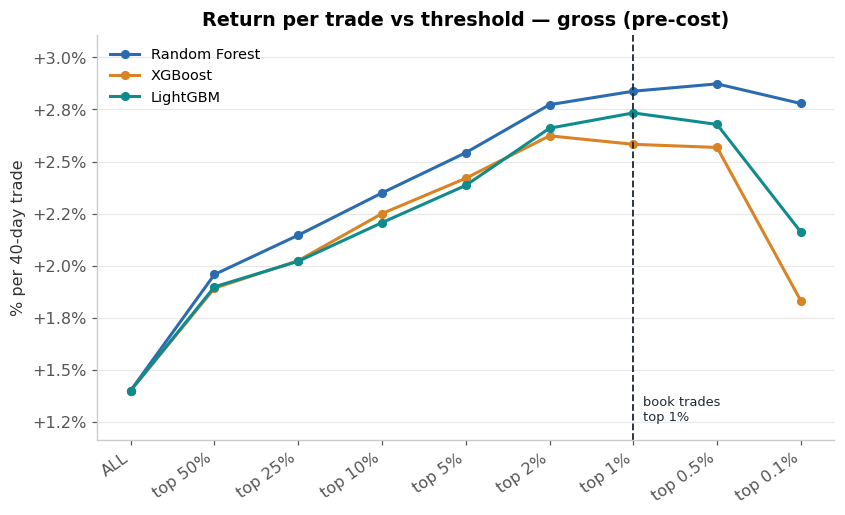

In [10]:
fig, ax = plt.subplots(figsize=(7.8, 4.8))
xs = np.arange(len(QS))
labs = RES["Random Forest"]["sweep"].threshold.tolist()
i99 = labs.index("top 1%")
for n_ in RES:
    ax.plot(xs, RES[n_]["sweep"]["gross"], "o-", color=COL[n_], lw=2, ms=5, label=n_)
ax.axvline(i99, color=INK, ls="--", lw=1.2)
# annotation pinned to the BOTTOM of the axes so it can never collide with the curves
ax.text(i99 + 0.12, 0.04, "book trades\ntop 1%", transform=ax.get_xaxis_transform(),
        fontsize=8.5, color=INK, va="bottom", ha="left")
ax.set_xticks(xs, labs, rotation=35, ha="right")
ax.set_title("Return per trade vs threshold — gross (pre-cost)")
ax.yaxis.set_major_formatter(pct1); ax.yaxis.set_major_locator(MultipleLocator(0.25))
ax.set_ylabel(f"% per {H}-day trade")
# zoom to the data: every value is well clear of zero, and the story is the divergence at the tail
lo = min(RES[n_]["sweep"]["gross"].min() for n_ in RES)
hi = max(RES[n_]["sweep"]["gross"].max() for n_ in RES)
pad = (hi - lo) * 0.16
ax.set_ylim(lo - pad, hi + pad)
ax.legend(loc="upper left", framealpha=0.9)
style(ax)
plt.tight_layout(); save("models_03_threshold_sweep")


This is the result. **The boosters roll over and RF does not.**

LightGBM peaks at the top 2% and falls away from there. XGBoost plateaus across the top 2% to top 1%,
then drops. Random Forest keeps climbing all the way to the top 0.5%.

At the top 1%, the threshold the book actually uses, RF earns **+1.21%** net per trade against
XGBoost's +0.95% and LightGBM's +0.76% — and the gap widens with further selectivity rather than
closing.

Cost is not the explanation. All three pay a similar toll at the top 1% (31bp for RF, 36bp and 35bp
for the boosters), so the difference is in the ranking, not the execution. The tail is where a
concentrated book lives, which makes a model that ranks the average name well but loses its grip at
the extreme the wrong trade-off here.

  → report/figures/models_04_tail_behaviour.png


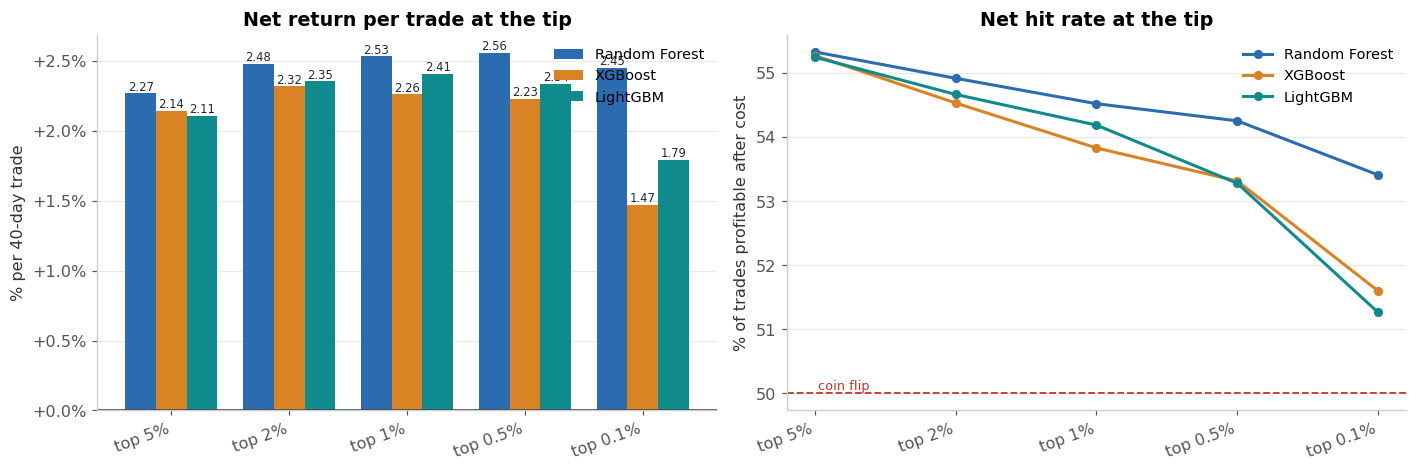

net % per trade at top 1% / top 0.1%, and the cost being paid:

Random Forest   top1% net +2.53% (cost 30bp, hit 54.5%)   |   top0.1% net +2.45% (median +0.96%)
XGBoost         top1% net +2.26% (cost 32bp, hit 53.8%)   |   top0.1% net +1.47% (median +0.42%)
LightGBM        top1% net +2.41% (cost 33bp, hit 54.2%)   |   top0.1% net +1.79% (median +0.35%)


In [11]:
TIP = ["top 5%", "top 2%", "top 1%", "top 0.5%", "top 0.1%"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
x = np.arange(len(TIP)); w = 0.26
for i, n in enumerate(RES):
    s = RES[n]["sweep"].set_index("threshold")
    a1.bar(x + (i - 1) * w, s.loc[TIP, "net"], w, color=COL[n], label=n)
    a2.plot(x, s.loc[TIP, "hit"], "o-", color=COL[n], lw=2, ms=5, label=n)
for i, n in enumerate(RES):
    s = RES[n]["sweep"].set_index("threshold")
    for j, v in enumerate(s.loc[TIP, "net"]):
        a1.text(j + (i - 1) * w, v + .02, f"{v:.2f}", ha="center", fontsize=7.6, color=INK)
a1.axhline(0, color=INK, lw=1)
a1.set_xticks(x, TIP, rotation=20, ha="right")
a1.set_title("Net return per trade at the tip")
a1.set_ylabel(f"% per {H}-day trade"); a1.yaxis.set_major_formatter(pct1); a1.legend()
style(a1)

a2.axhline(50, color=RED, ls="--", lw=1.2)
a2.text(0.02, 50.06, "coin flip", fontsize=8.5, color=RED)
a2.set_xticks(x, TIP, rotation=20, ha="right")
a2.set_title("Net hit rate at the tip")
a2.set_ylabel("% of trades profitable after cost"); a2.legend()
style(a2)
plt.tight_layout(); save("models_04_tail_behaviour")

print("net % per trade at top 1% / top 0.1%, and the cost being paid:\n")
for n in RES:
    s = RES[n]["sweep"].set_index("threshold")
    print(f"{n:<15s} top1% net {s.loc['top 1%','net']:+.2f}% (cost {s.loc['top 1%','cost']:.0f}bp, "
          f"hit {s.loc['top 1%','hit']:.1f}%)   |   "
          f"top0.1% net {s.loc['top 0.1%','net']:+.2f}% (median {s.loc['top 0.1%','median']:+.2f}%)")

The hit-rate panel explains the mechanism. All three decay toward a coin flip as the threshold
tightens, but the boosters get there faster — LightGBM drops below 50% at the top 0.1%, and its
median net trade there is **negative**. RF stays above 50% throughout.

So the boosters' extreme picks are not merely less profitable, they are close to uninformative.

---
## Verdict

**Random Forest wins, and it isn't close on the metric that matters.**

| | Random Forest | XGBoost | LightGBM |
|---|---|---|---|
| rank-IC | **+0.0367** | +0.0322 | +0.0322 |
| t (naive, as logged) | 17.7 | 15.2 | 15.1 |
| **t (corrected, NW-40)** | **5.58** | 4.97 | 5.12 |
| weakest fold | **+0.0236** | +0.0203 | +0.0217 |
| decile spread (gross) | **+1.46pp** | +1.24pp | +1.21pp |
| top-1% net per trade | **+1.21%** | +0.95% | +0.76% |
| top-0.1% net per trade | **+1.22%** | +0.44% | +0.32% |
| net return still rising at | **top 0.5%** | plateaus top 2-1% | peaks top 2% |
| net hit rate at top 0.1% | **52.7%** | 50.1% | 49.7% |
| runtime | 980s | **227s** | 233s |

The two boosters are statistically indistinguishable from each other and both sit below RF on every
quality measure while being 4x faster. Speed is not the binding constraint on a run done a handful of
times, so it doesn't buy anything here.

**Why bagging plausibly wins on this problem.** The signal is weak — an IC of 0.037 means the
features explain very little of any single stock's forward return. Boosting fits residuals
sequentially, so each tree chases what previous trees left over, and on a low signal-to-noise target
most of that residual *is* noise. Bagging independent deep trees and averaging attacks variance
instead, which is the dominant error term here. The tail behaviour is consistent with that reading:
the boosters' extreme predictions are where sequential residual-fitting has compounded the most
noise, and that is exactly where they fail.

**Caveats, stated plainly.**

- These are default-ish hyperparameters, not tuned. A properly tuned booster — stronger
  regularisation, lower learning rate, more trees, `min_child_samples` raised toward RF's ~199-row
  leaves — might close some of this gap. What's shown is the frozen configuration, not the ceiling.
- All three share one architecture-independent flaw: calibration slopes of 0.41-0.43, so predicted
  magnitudes are overstated by roughly 2.3x in every case. Fine for rank-based selection, wrong for
  return-proportional sizing.
- Books were built only for RF. No equity curve, Sharpe, or drawdown exists for either booster, and
  a signal comparison is not a portfolio comparison — dedup and equal-weight compounding both change
  the ranking. On this evidence there's no reason to spend the runs.

**Recommendation:** keep Random Forest as the frozen production model. The comparison is answered.